In [2]:
# -*- coding: utf-8 -*-
"""
PROJECT 3: HIERARCHICAL RISK PARITY (HRP) PORTFOLIO
Concept: Allocate capital based on risk clustering, not price predictions.
Tinker points: Change the asset list, rebalance frequency, or linkage method.
"""

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.optimize import minimize

# ------------------- 1. FETCH DIVERSE ASSET DATA -------------------
print("📥 Downloading ETF universe... (10 assets)")

# TINKER POINT: Swap these for individual stocks (AAPL, MSFT...) or crypto!
tickers = [
    "SPY",   # US Equities
    "TLT",   # Long-term Treasuries
    "GLD",   # Gold
    "XLK",   # Tech
    "XLF",   # Financials
    "XLE",   # Energy
    "XLV",   # Healthcare
    "XLI",   # Industrials
    "XLY",   # Consumer Discretionary
    "XLU"    # Utilities
]

# Download adjusted close
data = yf.download(tickers, start="2018-01-01", end="2024-01-01", progress=False)['Close']
data = data.dropna()
returns = data.pct_change().dropna()

print(f"✅ Loaded {len(data.columns)} assets from {data.index[0].date()} to {data.index[-1].date()}")

📥 Downloading ETF universe... (10 assets)
✅ Loaded 10 assets from 2018-01-02 to 2023-12-29


In [3]:
# ------------------- 2. HRP CORE FUNCTIONS -------------------
def get_clusters(corr_matrix, method='ward'):
    """
    Convert correlation to distance, then cluster.
    Tinker: Change linkage method to 'single', 'complete', or 'average'.
    """
    # Distance = sqrt(2 * (1 - correlation))
    dist = np.sqrt(2 * (1 - corr_matrix))
    # Condense to 1D array for scipy
    condensed_dist = squareform(dist, checks=False)
    # Hierarchical clustering
    clusters = linkage(condensed_dist, method=method)
    return clusters

def get_hrp_weights(returns):
    """
    Calculate HRP weights using the classic recursive bisection algorithm.
    """
    # 1. Compute covariance and correlation
    cov = returns.cov()
    corr = returns.corr()
    
    # 2. Get clusters
    clusters = get_clusters(corr)
    
    # 3. Recursive bisection (simplified version for clarity)
    # Start with all assets in one cluster
    asset_list = list(returns.columns)
    weights = pd.Series(1, index=asset_list)
    
    # We'll use a loop to split clusters based on the dendrogram
    # For tinkering clarity, I'll use a simpler approach: 
    # Allocate risk parity within clusters, then across clusters.
    
    # Step 3a: Get cluster labels (cut the tree into 3 clusters)
    # TINKER: Change '3' to '2' or '4' to force more/fewer clusters!
    cluster_labels = fcluster(clusters, t=3, criterion='maxclust')
    cluster_dict = {}
    for asset, label in zip(asset_list, cluster_labels):
        cluster_dict.setdefault(label, []).append(asset)
    
    # Step 3b: Compute cluster-level risk (average variance)
    cluster_vol = {}
    for label, members in cluster_dict.items():
        cluster_returns = returns[members]
        # Average covariance within cluster
        if len(members) > 1:
            cluster_cov = cluster_returns.cov().values
            # Cluster risk = sqrt(mean variance)
            cluster_vol[label] = np.sqrt(np.mean(np.diag(cluster_cov)))
        else:
            cluster_vol[label] = cluster_returns.std().values[0]
    
    # Step 3c: Allocate risk proportionally (inverse variance across clusters)
    total_risk = sum(1/v for v in cluster_vol.values())
    cluster_weights = {label: (1/v) / total_risk for label, v in cluster_vol.items()}
    
    # Step 3d: Within each cluster, allocate equal weight (or inverse variance)
    final_weights = {}
    for label, members in cluster_dict.items():
        if len(members) > 1:
            # Sub-cluster variance
            sub_returns = returns[members]
            sub_vol = sub_returns.std()
            inv_var = 1 / (sub_vol + 1e-8)
            sub_weights = inv_var / inv_var.sum()
            for asset, w in zip(members, sub_weights):
                final_weights[asset] = w * cluster_weights[label]
        else:
            final_weights[members[0]] = cluster_weights[label]
    
    return pd.Series(final_weights)

In [4]:
# ------------------- 3. BACKTEST: QUARTERLY REBALANCE -------------------
print("⚙️ Running HRP backtest with quarterly rebalance...")

# We'll rebalance on the first trading day of every quarter
rebalance_dates = returns.resample('Q').first().index
portfolio_returns = []

for i in range(len(rebalance_dates) - 1):
    rebalance_date = rebalance_dates[i]
    next_rebalance = rebalance_dates[i+1]
    
    # Use trailing 252 days (1 year) of returns to compute covariance
    lookback_start = rebalance_date - pd.Timedelta(days=252)
    lookback_returns = returns[lookback_start:rebalance_date]
    
    if len(lookback_returns) < 60:  # Skip early periods
        continue
        
    # Calculate HRP weights for this period
    weights = get_hrp_weights(lookback_returns)
    
    # Calculate portfolio return over the next quarter
    period_returns = returns[rebalance_date:next_rebalance]
    if len(period_returns) > 0:
        port_ret = (period_returns * weights).sum(axis=1)
        portfolio_returns.append(port_ret)

# Concatenate all period returns
portfolio_returns = pd.concat(portfolio_returns)
portfolio_equity = (1 + portfolio_returns).cumprod()

⚙️ Running HRP backtest with quarterly rebalance...


C:\Users\Jason Lam\AppData\Local\Temp\ipykernel_3700\4106532966.py:5: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  rebalance_dates = returns.resample('Q').first().index


In [5]:
# ------------------- 4. BENCHMARK: 60/40 (SPY/TLT) -------------------
benchmark_weights = pd.Series([0.6, 0.4], index=['SPY', 'TLT'])
benchmark_returns = (returns[['SPY', 'TLT']] * benchmark_weights).sum(axis=1)
benchmark_equity = (1 + benchmark_returns).cumprod()

# Align dates
start_date = max(portfolio_equity.index[0], benchmark_equity.index[0])
portfolio_equity = portfolio_equity[start_date:]
benchmark_equity = benchmark_equity[start_date:]

In [6]:
# ------------------- 5. PERFORMANCE METRICS -------------------
def compute_metrics(equity_series, name):
    rets = equity_series.pct_change().dropna()
    sharpe = np.sqrt(252) * rets.mean() / (rets.std() + 1e-8)
    dd = (equity_series.cummax() - equity_series) / (equity_series.cummax() + 1e-8)
    max_dd = dd.max()
    total_ret = (equity_series.iloc[-1] / equity_series.iloc[0] - 1) * 100
    print(f"{name}:")
    print(f"  Total Return: {total_ret:.2f}%")
    print(f"  Sharpe: {sharpe:.3f}")
    print(f"  Max Drawdown: {max_dd*100:.2f}%")
    return {'Sharpe': sharpe, 'MaxDD': max_dd, 'Return': total_ret}

print("\n" + "="*50)
print("📊 HRP PORTFOLIO vs 60/40 BENCHMARK")
print("="*50)
metrics_hrp = compute_metrics(portfolio_equity, "HRP Portfolio")
metrics_bench = compute_metrics(benchmark_equity, "60/40 (SPY/TLT)")


📊 HRP PORTFOLIO vs 60/40 BENCHMARK
HRP Portfolio:
  Total Return: 41.14%
  Sharpe: 0.543
  Max Drawdown: 23.72%
60/40 (SPY/TLT):
  Total Return: 57.19%
  Sharpe: 0.683
  Max Drawdown: 27.24%


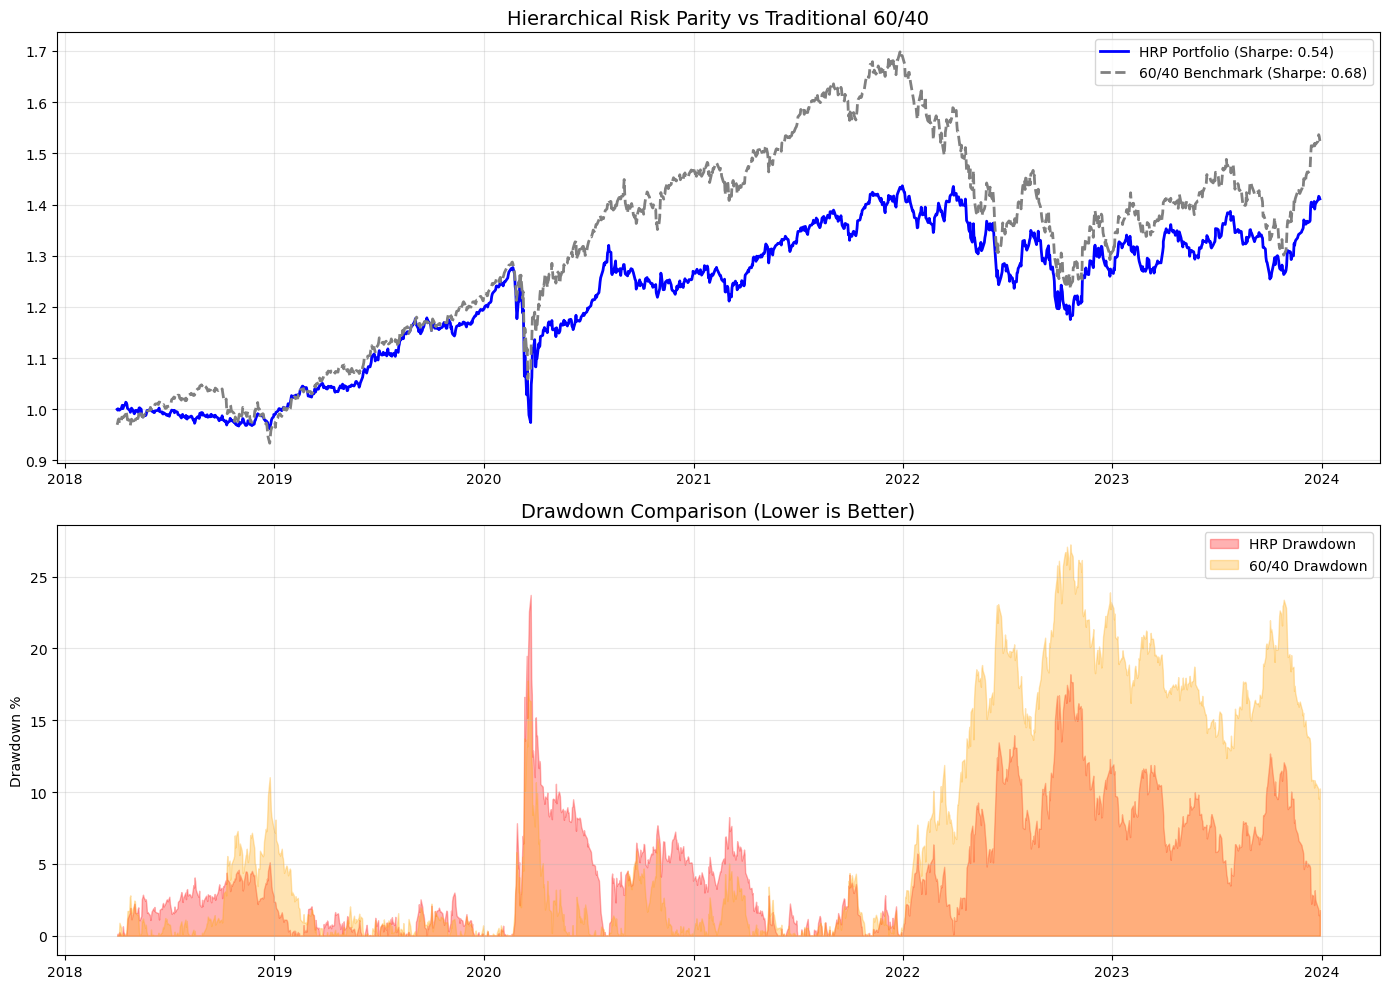

In [7]:
# ------------------- 6. PLOTTING -------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Equity Curves
axes[0].plot(portfolio_equity.index, portfolio_equity, 
             label=f'HRP Portfolio (Sharpe: {metrics_hrp["Sharpe"]:.2f})', 
             color='blue', linewidth=2)
axes[0].plot(benchmark_equity.index, benchmark_equity, 
             label=f'60/40 Benchmark (Sharpe: {metrics_bench["Sharpe"]:.2f})', 
             color='gray', linewidth=2, linestyle='--')
axes[0].set_title('Hierarchical Risk Parity vs Traditional 60/40', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Drawdown Comparison
hrp_dd = (portfolio_equity.cummax() - portfolio_equity) / (portfolio_equity.cummax() + 1e-8)
bench_dd = (benchmark_equity.cummax() - benchmark_equity) / (benchmark_equity.cummax() + 1e-8)
axes[1].fill_between(portfolio_equity.index, hrp_dd * 100, label='HRP Drawdown', color='red', alpha=0.3)
axes[1].fill_between(benchmark_equity.index, bench_dd * 100, label='60/40 Drawdown', color='orange', alpha=0.3)
axes[1].set_title('Drawdown Comparison (Lower is Better)', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_ylabel('Drawdown %')

plt.tight_layout()
plt.show()

In [8]:
# ------------------- 7. TINKERING INSTRUCTIONS --------------------
print("\n🔧 HOW TO TINKER WITH THIS PROJECT:")
print("="*50)
print("1. Change `tickers` list -> add 'BTC-USD' or 'VNQ' (Real Estate).")
print("2. Change `t=3` in `fcluster(...)` to `t=2` or `t=4` (more/fewer clusters).")
print("3. Change linkage `method='ward'` to `'complete'` or `'average'`.")
print("4. Change rebalance frequency from `'Q'` (quarterly) to `'M'` (monthly).")
print("5. Replace the 60/40 benchmark with a simple 'Equal Weight' portfolio.")


🔧 HOW TO TINKER WITH THIS PROJECT:
1. Change `tickers` list -> add 'BTC-USD' or 'VNQ' (Real Estate).
2. Change `t=3` in `fcluster(...)` to `t=2` or `t=4` (more/fewer clusters).
3. Change linkage `method='ward'` to `'complete'` or `'average'`.
4. Change rebalance frequency from `'Q'` (quarterly) to `'M'` (monthly).
5. Replace the 60/40 benchmark with a simple 'Equal Weight' portfolio.
